# Rank Selection for Tensor Decomposition

This notebook implements multiple rank selection diagnostics:

1. **CORCONDIA** - Core consistency (CP structure quality)
2. **Reconstruction Error** - Training fit (look for elbow)
3. **Holdout Validation** - Generalization to unseen data

## CORCONDIA (Core Consistency Diagnostic)

Measures how well data fits a CP/PARAFAC model:
- **≈100%** -> Excellent CP structure
- **>80%** -> Acceptable
- **<50%** -> Poor fit, rank too high

Formula: `100 × (1 - ||G - I||²_F / R)` where G is Tucker core, I is identity

## Reconstruction Error

Sum of squared errors between data and CP reconstruction:
- Always decreases with rank
- Look for **elbow** (diminishing returns)

## Holdout Validation

Randomly mask 10% of entries, predict them:
- Lower error = better generalization
- Prevents overfitting

In [1]:
import pickle
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorly as tl
from tensorly.decomposition import parafac
from tensorly.cp_tensor import cp_to_tensor
tl.set_backend('numpy')

np.random.seed(42)
print("Libraries loaded")

Libraries loaded


## Load Data

Run `video_level_analysis.ipynb` first; it saves the similarity tensor to `data/cpd_results_31videos.pkl`.


In [2]:
# Load the 3 x 31 x 31 cosine-similarity tensor built in video_level_analysis.ipynb
import sys
sys.path.append('../src')  # the pickle also holds SymCPD models defined in src/tensor.py

with open('../data/cpd_results_31videos.pkl', 'rb') as f:
    saved = pickle.load(f)

tensor_np = np.asarray(saved['tensor'], dtype=np.float64)   # (3 phases, 31 videos, 31 videos)
video_metadata = saved['video_metadata']

print(f"Tensor shape: {tensor_np.shape}")
print(f"Videos: {len(video_metadata)}")
print(f"Frobenius norm: {np.linalg.norm(tensor_np):.2f}")
print(f"Value range: [{tensor_np.min():.3f}, {tensor_np.max():.3f}]")


Tensor shape: (3, 31, 31)
Videos: 31
Frobenius norm: 37.51
Value range: [0.000, 1.000]


## Rank Selection Metrics

Implementations of CORCONDIA, reconstruction error, and holdout validation (masked entries are treated as unobserved during the fit).


In [3]:
def _superdiag_identity(rank):
    """Create superdiagonal identity core tensor."""
    Icore = np.zeros((rank, rank, rank))
    for r in range(rank):
        Icore[r, r, r] = 1.0
    return Icore


def pinv_stable(M, rcond=1e-8):
    """
    Compute stable pseudoinverse with explicit singular value truncation.
    
    More numerically stable than np.linalg.pinv for ill-conditioned matrices.
    """
    U, s, Vh = np.linalg.svd(M, full_matrices=False)
    tol = rcond * (s.max() if s.size > 0 else 0.0)
    s_inv = np.where(s > tol, 1.0 / s, 0.0)
    return (Vh.T * s_inv) @ U.T


def compute_corcondia(tensor, rank, n_iter_max=1000, verbose=False, random_state=42):
    """
    Compute CORCONDIA (Core Consistency Diagnostic).
    
    Uses stable pseudoinverses and proper weight handling.
    Returns percentage (100 = perfect CP structure).
    """
    I, J, K = tensor.shape
    
    if rank > min(I, J, K) and verbose:
        print(f"Warning: R={rank} > min({I},{J},{K})={min(I,J,K)}")
    
    # Fit CP with normalized factors
    cp_result = parafac(
        tensor, rank=rank, n_iter_max=n_iter_max,
        init='random', random_state=random_state,
        normalize_factors=True
    )
    
    weights, factors = cp_result
    
    # Distribute weights equally: λ^(1/3) into each factor
    lam = np.ones(rank) if weights is None else tl.to_numpy(weights)
    scale = lam ** (1.0 / 3.0)
    
    A = tl.to_numpy(factors[0]) * scale[None, :]
    B = tl.to_numpy(factors[1]) * scale[None, :]
    C = tl.to_numpy(factors[2]) * scale[None, :]
    
    # Compute stable pseudoinverses (handles ill-conditioned matrices)
    A_pinv = pinv_stable(A, rcond=1e-8)
    B_pinv = pinv_stable(B, rcond=1e-8)
    C_pinv = pinv_stable(C, rcond=1e-8)
    
    # Tucker core: G = X ×₁ A⁺ ×₂ B⁺ ×₃ C⁺
    G = np.tensordot(tensor, A_pinv, axes=([0], [1]))
    G = np.tensordot(G, B_pinv, axes=([0], [1]))
    G = np.tensordot(G, C_pinv, axes=([0], [1]))
    
    # Compare to identity
    I_core = _superdiag_identity(rank)
    numerator = float(np.sum((G - I_core) ** 2))
    denominator = float(rank)
    
    corcondia = 100.0 * (1.0 - numerator / denominator)
    
    if verbose:
        diag = [G[r,r,r] for r in range(rank)]
        print(f"  CORCONDIA: {corcondia:.2f}%")
        print(f"  Core diagonal: {[f'{x:.3f}' for x in diag]}")
    
    return corcondia


def compute_reconstruction_error(tensor, rank, n_iter_max=1000, random_state=42):
    """
    Compute reconstruction error (SSE).
    
    Lower is better. Look for elbow.
    """
    cp_result = parafac(
        tensor, rank=rank, n_iter_max=n_iter_max,
        init='random', random_state=random_state,
        normalize_factors=True
    )
    
    reconstruction = cp_to_tensor(cp_result)
    sse = float(np.sum((tensor - reconstruction) ** 2))
    
    return sse


def compute_holdout_error(tensor, rank, holdout_fraction=0.1, 
                         n_iter_max=1000, n_init=5, random_state=42):
    """
    Compute holdout validation error with proper masking.
    
    CRITICAL: Uses mask parameter to ignore held-out entries during fitting.
    This prevents information leakage (treating zeros as real observations).
    
    Multiple random restarts (n_init) are used to avoid local minima.
    
    Returns RMSE on held-out entries.
    """
    rng = np.random.default_rng(random_state)
    
    # Create mask: 1 = observed, 0 = held-out
    mask = np.ones_like(tensor, dtype=float)
    n_entries = tensor.size
    n_holdout = int(holdout_fraction * n_entries)
    
    # Randomly select entries to hold out
    holdout_idx = rng.choice(n_entries, size=n_holdout, replace=False)
    mask.reshape(-1)[holdout_idx] = 0.0
    
    # Multiple restarts to avoid local minima
    best_cp = None
    best_train_loss = np.inf
    
    for seed in range(n_init):
        cp_result = parafac(
            tensor, 
            rank=rank, 
            n_iter_max=n_iter_max,
            init='random', 
            random_state=random_state + seed,
            normalize_factors=True,
            mask=mask  # KEY: Only fit observed entries!
        )
        
        # Evaluate training loss on observed entries
        Xhat = cp_to_tensor(cp_result)
        train_loss = float(np.sum(mask * (tensor - Xhat) ** 2))
        
        if train_loss < best_train_loss:
            best_cp = cp_result
            best_train_loss = train_loss
    
    # Compute error on held-out entries only
    Xhat = cp_to_tensor(best_cp)
    H = (1.0 - mask)  # Held-out indicator
    n_holdout_actual = int(np.sum(H))
    
    if n_holdout_actual == 0:
        return 0.0
    
    mse = float(np.sum(H * (tensor - Xhat) ** 2)) / n_holdout_actual
    rmse = np.sqrt(mse)
    
    return rmse


## Compute All Metrics

In [4]:
# Test different rank ranges for different metrics
# CORCONDIA: Only valid when R <= min(I,J,K) = 3
# Reconstruction & Holdout: Can test higher ranks to see overfitting
corcondia_ranks = range(1, min(tensor_np.shape) + 1)  # 1-3
full_ranks = range(1, 11)  # 1-10 for reconstruction and holdout

print(f"CORCONDIA will test ranks: {list(corcondia_ranks)}")
print(f"Reconstruction & Holdout will test ranks: {list(full_ranks)}")
print(f"Tensor shape: {tensor_np.shape}")
print("=" * 70)

all_results = {
    'rank': [],
    'corcondia': [],
    'reconstruction_sse': [],
    'holdout_error': []
}

# First compute all metrics for ranks where CORCONDIA is valid (1-3)
for rank in corcondia_ranks:
    print(f"\nRank {rank}:")
    
    # CORCONDIA
    corcondia = compute_corcondia(tensor_np, rank, n_iter_max=2000, 
                                  verbose=True, random_state=42)
    
    # Reconstruction error
    sse = compute_reconstruction_error(tensor_np, rank, n_iter_max=2000, random_state=42)
    print(f"  Reconstruction SSE: {sse:.2f}")
    
    # Holdout error (average over 3 trials with proper masking)
    print(f"  Computing holdout error (3 trials, 5 restarts each)...")
    holdout_errors = []
    for trial in range(3):
        rmse = compute_holdout_error(
            tensor_np, rank, 
            holdout_fraction=0.1,
            n_iter_max=1000,
            n_init=5,
            random_state=42 + trial
        )
        holdout_errors.append(rmse)
    
    avg_holdout = np.mean(holdout_errors)
    std_holdout = np.std(holdout_errors)
    print(f"  Holdout RMSE: {avg_holdout:.2f} ± {std_holdout:.2f}")
    
    all_results['rank'].append(rank)
    all_results['corcondia'].append(corcondia)
    all_results['reconstruction_sse'].append(sse)
    all_results['holdout_error'].append(avg_holdout)

# Now compute only reconstruction and holdout for higher ranks (4-10)
for rank in range(max(corcondia_ranks) + 1, max(full_ranks) + 1):
    print(f"\nRank {rank}:")
    print(f"  Skipping CORCONDIA (only valid for R <= {max(corcondia_ranks)})")
    
    # Reconstruction error
    sse = compute_reconstruction_error(tensor_np, rank, n_iter_max=2000, random_state=42)
    print(f"  Reconstruction SSE: {sse:.2f}")
    
    # Holdout error
    print(f"  Computing holdout error (3 trials, 5 restarts each)...")
    holdout_errors = []
    for trial in range(3):
        rmse = compute_holdout_error(
            tensor_np, rank, 
            holdout_fraction=0.1,
            n_iter_max=1000,
            n_init=5,
            random_state=42 + trial
        )
        holdout_errors.append(rmse)
    
    avg_holdout = np.mean(holdout_errors)
    std_holdout = np.std(holdout_errors)
    print(f"  Holdout RMSE: {avg_holdout:.2f} ± {std_holdout:.2f}")
    
    all_results['rank'].append(rank)
    all_results['corcondia'].append(None)  # No CORCONDIA for high ranks
    all_results['reconstruction_sse'].append(sse)
    all_results['holdout_error'].append(avg_holdout)

print("\n" + "=" * 70)
print("All metrics computed")

CORCONDIA will test ranks: [1, 2, 3]
Reconstruction & Holdout will test ranks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Tensor shape: (3, 31, 31)

Rank 1:
  CORCONDIA: 100.00%
  Core diagonal: ['1.000']
  Reconstruction SSE: 106.83
  Computing holdout error (3 trials, 5 restarts each)...
  Holdout RMSE: 0.19 ± 0.01

Rank 2:
  CORCONDIA: 100.00%
  Core diagonal: ['1.002', '0.999']
  Reconstruction SSE: 42.66
  Computing holdout error (3 trials, 5 restarts each)...
  Holdout RMSE: 0.13 ± 0.00

Rank 3:
  CORCONDIA: 94.15%
  Core diagonal: ['1.029', '1.000', '0.884']
  Reconstruction SSE: 15.72
  Computing holdout error (3 trials, 5 restarts each)...
  Holdout RMSE: 0.08 ± 0.00

Rank 4:
  Skipping CORCONDIA (only valid for R <= 3)
  Reconstruction SSE: 7.65
  Computing holdout error (3 trials, 5 restarts each)...
  Holdout RMSE: 0.05 ± 0.01

Rank 5:
  Skipping CORCONDIA (only valid for R <= 3)
  Reconstruction SSE: 5.85
  Computing holdout error (3 trials, 5 restarts each)...
  Holdout RMSE: 0.05 ±

## Visualize All Metrics

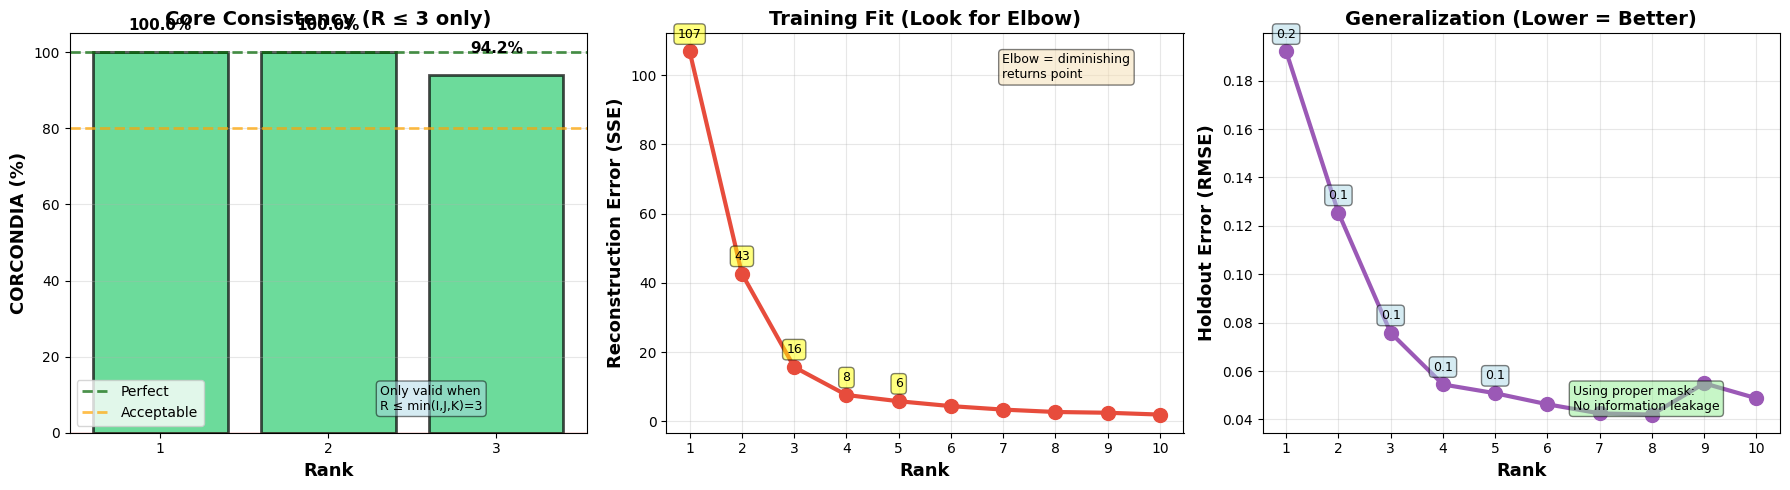


Saved: ../data/rank_selection_all_metrics.png


In [5]:
# Create 3-panel comparison with different rank ranges
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Filter data for CORCONDIA (only ranks with valid values)
corcondia_data = [(r, c) for r, c in zip(all_results['rank'], all_results['corcondia']) if c is not None]
corcondia_ranks = [r for r, c in corcondia_data]
corcondia_values = [c for r, c in corcondia_data]

# Panel 1: CORCONDIA (only ranks 1-3)
ax1 = axes[0]
colors = ['#2ecc71' if c > 80 else '#e74c3c' for c in corcondia_values]
ax1.bar(corcondia_ranks, corcondia_values, 
       color=colors, alpha=0.7, edgecolor='black', linewidth=2)

ax1.axhline(y=100, color='darkgreen', linestyle='--', linewidth=2, label='Perfect', alpha=0.7)
ax1.axhline(y=80, color='orange', linestyle='--', linewidth=2, label='Acceptable', alpha=0.7)
ax1.axhline(y=0, color='red', linestyle='-', linewidth=1, alpha=0.5)

for rank, corcondia in zip(corcondia_ranks, corcondia_values):
    ax1.text(rank, corcondia + 5, f"{corcondia:.1f}%", 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xlabel('Rank', fontsize=13, fontweight='bold')
ax1.set_ylabel('CORCONDIA (%)', fontsize=13, fontweight='bold')
ax1.set_title('Core Consistency (R ≤ 3 only)', fontsize=14, fontweight='bold')
ax1.set_xticks(corcondia_ranks)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Add note about validity range
textstr = 'Only valid when\nR ≤ min(I,J,K)=3'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.5)
ax1.text(0.60, 0.05, textstr, transform=ax1.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=props)

# Panel 2: Reconstruction Error (all ranks 1-10)
ax2 = axes[1]
ax2.plot(all_results['rank'], all_results['reconstruction_sse'], 
        'o-', linewidth=3, markersize=10, color='#e74c3c')

for rank, sse in zip(all_results['rank'], all_results['reconstruction_sse']):
    if rank <= 5:  # Only label first 5 to avoid clutter
        ax2.annotate(f"{sse:.0f}", xy=(rank, sse), xytext=(0, 10), 
                    textcoords='offset points', ha='center', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

ax2.set_xlabel('Rank', fontsize=13, fontweight='bold')
ax2.set_ylabel('Reconstruction Error (SSE)', fontsize=13, fontweight='bold')
ax2.set_title('Training Fit (Look for Elbow)', fontsize=14, fontweight='bold')
ax2.set_xticks(all_results['rank'])
ax2.grid(True, alpha=0.3)

textstr = 'Elbow = diminishing\nreturns point'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax2.text(0.65, 0.95, textstr, transform=ax2.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

# Panel 3: Holdout Error (RMSE) (all ranks 1-10)
ax3 = axes[2]
ax3.plot(all_results['rank'], all_results['holdout_error'], 
        'o-', linewidth=3, markersize=10, color='#9b59b6')

for rank, he in zip(all_results['rank'], all_results['holdout_error']):
    if rank <= 5:  # Only label first 5 to avoid clutter
        ax3.annotate(f"{he:.1f}", xy=(rank, he), xytext=(0, 10), 
                    textcoords='offset points', ha='center', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.5))

ax3.set_xlabel('Rank', fontsize=13, fontweight='bold')
ax3.set_ylabel('Holdout Error (RMSE)', fontsize=13, fontweight='bold')
ax3.set_title('Generalization (Lower = Better)', fontsize=14, fontweight='bold')
ax3.set_xticks(all_results['rank'])
ax3.grid(True, alpha=0.3)

# Add note about proper masking
textstr = 'Using proper mask:\nNo information leakage'
props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.5)
ax3.text(0.60, 0.05, textstr, transform=ax3.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=props)

plt.tight_layout()
plt.savefig('../data/rank_selection_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: ../data/rank_selection_all_metrics.png")

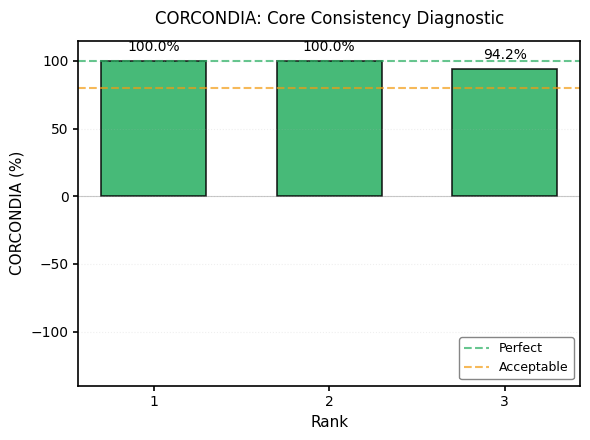

Saved: figures/rank_selection_corcondia.png


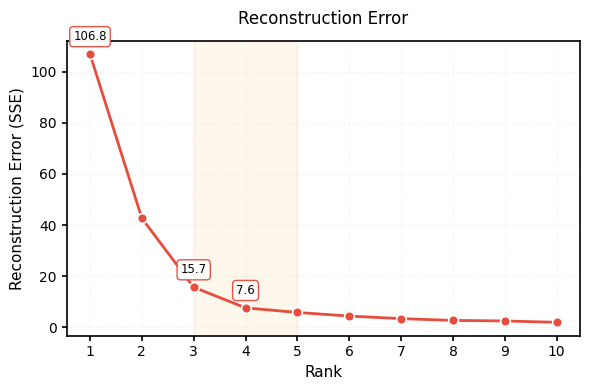

Saved: figures/rank_selection_reconstruction.png


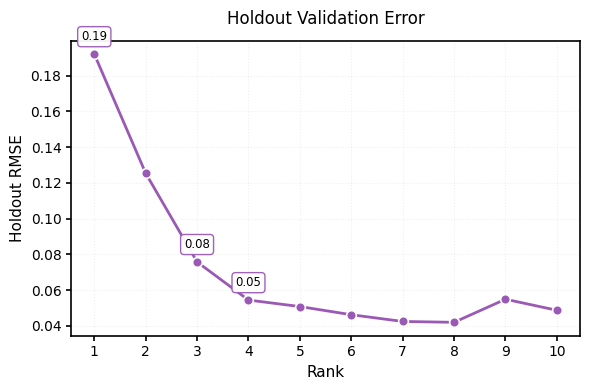

Saved: figures/rank_selection_holdout.png

Rank selection figures saved to figures/


In [6]:
# Create 3 separate publication-quality figures for paper

# Figure style
import matplotlib
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['axes.linewidth'] = 1.2
matplotlib.rcParams['xtick.major.width'] = 1.2
matplotlib.rcParams['ytick.major.width'] = 1.2

# Filter data for CORCONDIA
corcondia_data = [(r, c) for r, c in zip(all_results['rank'], all_results['corcondia']) if c is not None]
corcondia_ranks = [r for r, c in corcondia_data]
corcondia_values = [c for r, c in corcondia_data]

# =============================================================================
# Figure 1: CORCONDIA - Clean version with no overlap
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))

colors = ['#27ae60' if c > 80 else '#e74c3c' for c in corcondia_values]
bars = ax.bar(corcondia_ranks, corcondia_values, 
              color=colors, alpha=0.85, edgecolor='black', linewidth=1.2, width=0.6)

# Reference lines
ax.axhline(y=100, color='#27ae60', linestyle='--', linewidth=1.5, alpha=0.7, label='Perfect')
ax.axhline(y=80, color='#f39c12', linestyle='--', linewidth=1.5, alpha=0.7, label='Acceptable')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.4)

# Value labels - smart positioning to avoid overlap with lines
for rank, corcondia in zip(corcondia_ranks, corcondia_values):
    if corcondia > 90:  # Well above acceptable line
        y_pos = corcondia + 5
        va = 'bottom'
    elif corcondia > 70 and corcondia < 90:  # Between lines
        y_pos = corcondia
        va = 'center'
    elif corcondia > -20:  # Just below zero
        y_pos = corcondia - 8
        va = 'top'
    else:  # Far below zero (the -109 case)
        y_pos = corcondia - 15  # Position well below to avoid line
        va = 'top'
    
    ax.text(rank, y_pos, f"{corcondia:.1f}%", 
            ha='center', va=va, fontsize=10)

ax.set_xlabel('Rank', fontsize=11)
ax.set_ylabel('CORCONDIA (%)', fontsize=11)
ax.set_title('CORCONDIA: Core Consistency Diagnostic', fontsize=12, pad=12)
ax.set_xticks(corcondia_ranks)
ax.set_ylim(-140, 115)  # Extended bottom to fit -109 label
ax.legend(fontsize=9, loc='lower right', framealpha=0.95, edgecolor='gray')
ax.grid(True, alpha=0.2, axis='y', linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.savefig('../figures/rank_selection_corcondia.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: figures/rank_selection_corcondia.png")

# =============================================================================
# Figure 2: Reconstruction Error
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

reconstruction_sse = list(all_results['reconstruction_sse'])

ax.plot(all_results['rank'], reconstruction_sse,
        'o-', linewidth=2, markersize=7, color='#e74c3c',
        markeredgecolor='white', markeredgewidth=1.2)

# Value labels for key ranks only
for rank in [1, 3, 4]:
    idx = rank - 1
    sse = reconstruction_sse[idx]
    ax.annotate(f"{sse:.1f}", xy=(rank, sse), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                         edgecolor='#e74c3c', alpha=0.95, linewidth=1))

ax.set_xlabel('Rank', fontsize=11)
ax.set_ylabel('Reconstruction Error (SSE)', fontsize=11)
ax.set_title('Reconstruction Error', fontsize=12, pad=12)
ax.set_xticks(all_results['rank'])
ax.grid(True, alpha=0.2, linestyle=':', linewidth=0.8)

# Subtle elbow highlight
ax.axvspan(3, 5, alpha=0.08, color='#f39c12')

plt.tight_layout()
plt.savefig('../figures/rank_selection_reconstruction.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: figures/rank_selection_reconstruction.png")

# =============================================================================
# Figure 3: Holdout Validation
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.plot(all_results['rank'], all_results['holdout_error'], 
        'o-', linewidth=2, markersize=7, color='#9b59b6',
        markeredgecolor='white', markeredgewidth=1.2)

# Minimal value labels for key ranks only
for rank in [1, 3, 4]:
    idx = rank - 1
    he = all_results['holdout_error'][idx]
    ax.annotate(f"{he:.2f}", xy=(rank, he), xytext=(0, 10), 
                textcoords='offset points', ha='center', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                         edgecolor='#9b59b6', alpha=0.95, linewidth=1))

ax.set_xlabel('Rank', fontsize=11)
ax.set_ylabel('Holdout RMSE', fontsize=11)
ax.set_title('Holdout Validation Error', fontsize=12, pad=12)
ax.set_xticks(all_results['rank'])
ax.grid(True, alpha=0.2, linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.savefig('../figures/rank_selection_holdout.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: figures/rank_selection_holdout.png")

print("\n" + "="*70)
print("Rank selection figures saved to figures/")
print("="*70)